In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def set_paper_style() -> None:
    mpl.rcParams.update({
        "figure.figsize": (10, 6),
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "serif",
        "font.size": 14,
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.alpha": 0.4,
        "grid.linewidth": 0.8,
        "lines.linewidth": 2.0,
        "patch.linewidth": 1.2,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
    })

set_paper_style()

In [22]:
from __future__ import annotations

import json
from pathlib import Path
import sys

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

EXPERIMENT = "hazard_noise_sigma_020"
SEED = 42
SIGMA = 0.20
TOP_K = 1000

RNG = np.random.default_rng(SEED)

# Resolve repo root
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

assert (REPO_ROOT / "src").exists(), f"Could not find repo root from {Path.cwd()}"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.rtm.io_hazard import load_rtm_pluvial_v1_buildings

OUTPUT_DIR = REPO_ROOT / "outputs" / "phase2" / EXPERIMENT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Experiment: {EXPERIMENT}")
print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")

Experiment: hazard_noise_sigma_020
Repo root: /Users/habnetic/habnetic/projects/resilient-housing-bayes
Output dir: /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/hazard_noise_sigma_020


In [23]:
def perturb_hazard(h: np.ndarray, sigma: float = 0.10, seed: int = 42) -> np.ndarray:
    """Add Gaussian noise to a standardised hazard proxy."""
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=sigma, size=h.shape)
    return h + noise


def compute_topk_membership_probability(prob_draws: np.ndarray, k: int) -> np.ndarray:
    """
    Compute posterior top-k membership probability for each asset.

    prob_draws: shape (n_draws, n_assets)
    """
    n_draws, n_assets = prob_draws.shape
    membership = np.zeros((n_draws, n_assets), dtype=np.uint8)

    for s in range(n_draws):
        idx = np.argpartition(prob_draws[s], -k)[-k:]
        membership[s, idx] = 1

    return membership.mean(axis=0)


def compute_borderline_share(topk_prob: np.ndarray, low: float = 0.2, high: float = 0.8) -> float:
    """Share of assets near the decision boundary."""
    mask = (topk_prob > low) & (topk_prob < high)
    return float(mask.mean())


def save_json(data: dict, path: Path) -> None:
    path.write_text(json.dumps(data, indent=2), encoding='utf-8')

In [24]:
# === LOAD BASELINE DATA (COPIED FROM NOTEBOOK 7) ===

# --- Load outcome ---
Y_PATH = REPO_ROOT / "outputs" / "rtm" / "outcomes" / "Y_damage_v1b_p05.parquet"

print(Y_PATH)
print(Y_PATH.exists())
list((REPO_ROOT / "outputs" / "rtm").glob("**/*.parquet"))

assert Y_PATH.exists(), "Outcome file missing."
Y_df = pd.read_parquet(Y_PATH)

# --- Load exposure ---
E_PATH = REPO_ROOT / "outputs" / "rtm" / "water_exposure_Ehat_v0.parquet"
E_df = pd.read_parquet(E_PATH)[["bldg_id", "E_hat"]]

# --- Load hazard ---
haz_df = load_rtm_pluvial_v1_buildings()

# --- Merge full dataset ---
df_full = Y_df.merge(E_df, on="bldg_id", validate="one_to_one")
df_full = df_full.merge(haz_df, on="bldg_id", validate="one_to_one")

print("Full rows:", len(df_full))

# --- Subsample (same as baseline!) ---
N = 5000
df = df_full.sample(N, random_state=42).reset_index(drop=True)

print("Subsample rows:", len(df))

# --- Standardisation (COPY EXACTLY) ---
def zscore(x: pd.Series) -> pd.Series:
    mu = x.mean()
    sd = x.std(ddof=1)
    return (x - mu) / sd

df["E_std"] = zscore(df["E_hat"])
df["H_std"] = zscore(df["H_pluvial_v1_mm"])

print("E_std mean/std:", df["E_std"].mean(), df["E_std"].std(ddof=1))
print("H_std mean/std:", df["H_std"].mean(), df["H_std"].std(ddof=1))

/Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/rtm/outcomes/Y_damage_v1b_p05.parquet
True
Full rows: 221324
Subsample rows: 5000
E_std mean/std: 2.842170943040401e-18 1.0
H_std mean/std: -5.561066e-06 0.99999994


In [25]:
# --- Phase 2: Hazard perturbation ---

# Keep baseline copy
df["H_std_base"] = df["H_std"].copy()

# Apply perturbation to standardized hazard
df["H_std"] = perturb_hazard(df["H_std"].values, sigma=SIGMA, seed=SEED)

print("After perturbation:")
print("H_std mean/std:", df["H_std"].mean(), df["H_std"].std(ddof=1))

# --- Baseline (σ = 0.00) ---
"""
if "H_std_base" not in df.columns:
    df["H_std_base"] = df["H_std"].copy()

df["H_std"] = df["H_std_base"].copy()

print("Baseline H_std mean/std:", df["H_std"].mean(), df["H_std"].std(ddof=1))
"""

After perturbation:
H_std mean/std: -0.003980971918736041 1.0179356267533448


'\nif "H_std_base" not in df.columns:\n    df["H_std_base"] = df["H_std"].copy()\n\ndf["H_std"] = df["H_std_base"].copy()\n\nprint("Baseline H_std mean/std:", df["H_std"].mean(), df["H_std"].std(ddof=1))\n'

In [26]:
coords = {"obs_id": np.arange(len(df))}

with pm.Model(coords=coords) as model:

    E_data = pm.Data("E_std", df["E_std"].values, dims="obs_id")
    H_data = pm.Data("H_std", df["H_std"].values, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0, sigma=2.5)
    beta_E = pm.Normal("beta_E", mu=0, sigma=2.5)
    beta_H = pm.Normal("beta_H", mu=0, sigma=2.5)

    logit_p = alpha + beta_E * E_data + beta_H * H_data
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")

    Y_obs = pm.Bernoulli(
        "Y_obs",
        p=p,
        observed=df["Y_damage_v1b"].values,
        dims="obs_id",
    )

    idata = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.9,
        random_seed=SEED,
        return_inferencedata=True,
    )

/Users/habnetic/habnetic/projects/resilient-housing-bayes/.venv/lib/python3.11/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta_E, beta_H]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 20 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [27]:
az.summary(idata, var_names=["alpha", "beta_E", "beta_H"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-3.019,0.086,-3.198,-2.875,0.004,0.003,454.0,489.0,1.0
beta_E,1.072,0.099,0.890,1.253,0.004,0.003,494.0,627.0,1.0
beta_H,0.621,0.048,0.530,0.715,0.002,0.001,597.0,524.0,1.0


In [28]:
az.to_netcdf(idata, OUTPUT_DIR / "idata.nc")
print("Saved:", OUTPUT_DIR / "idata.nc")

Saved: /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/hazard_noise_sigma_020/idata.nc


In [29]:
# Posterior mean probability per building
p_post = idata.posterior["p"].mean(dim=("chain", "draw")).values
df["p_post_mean"] = p_post

# Rank by posterior mean
df["rank_post_mean"] = df["p_post_mean"].rank(ascending=False)

# Top-k membership probability
p_samples = idata.posterior["p"].stack(sample=("chain", "draw")).values

topk_counts = np.zeros(len(df))

for s in range(p_samples.shape[1]):
    idx = np.argsort(-p_samples[:, s])[:TOP_K]
    topk_counts[idx] += 1

topk_prob = topk_counts / p_samples.shape[1]
df["topk_prob"] = topk_prob

print("Top-k probability summary:")
print(df["topk_prob"].describe())

Top-k probability summary:
count    5000.000000
mean        0.200000
std         0.392433
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: topk_prob, dtype: float64


In [30]:
asset_metrics = df[[
    "bldg_id",
    "p_post_mean",
    "rank_post_mean",
    "topk_prob",
]].copy()

asset_metrics.to_parquet(OUTPUT_DIR / "asset_metrics.parquet", index=False)
print("Saved:", OUTPUT_DIR / "asset_metrics.parquet")

Saved: /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/hazard_noise_sigma_020/asset_metrics.parquet


In [31]:
borderline_share = ((df["topk_prob"] > 0.2) & (df["topk_prob"] < 0.8)).mean()
print("Borderline share:", borderline_share)

Borderline share: 0.0176


In [32]:
print("Correlation H_std_base vs H_std:", np.corrcoef(df["H_std_base"], df["H_std"])[0, 1])

Correlation H_std_base vs H_std: 0.980531832206319


Under Gaussian perturbations of the hazard proxy (σ = 0.10–0.30),
the share of borderline assets increases slightly (≈1.5% → 1.7%)
but remains stable thereafter.

Decision instability is confined to a narrow region and does not
propagate across the full ranking.

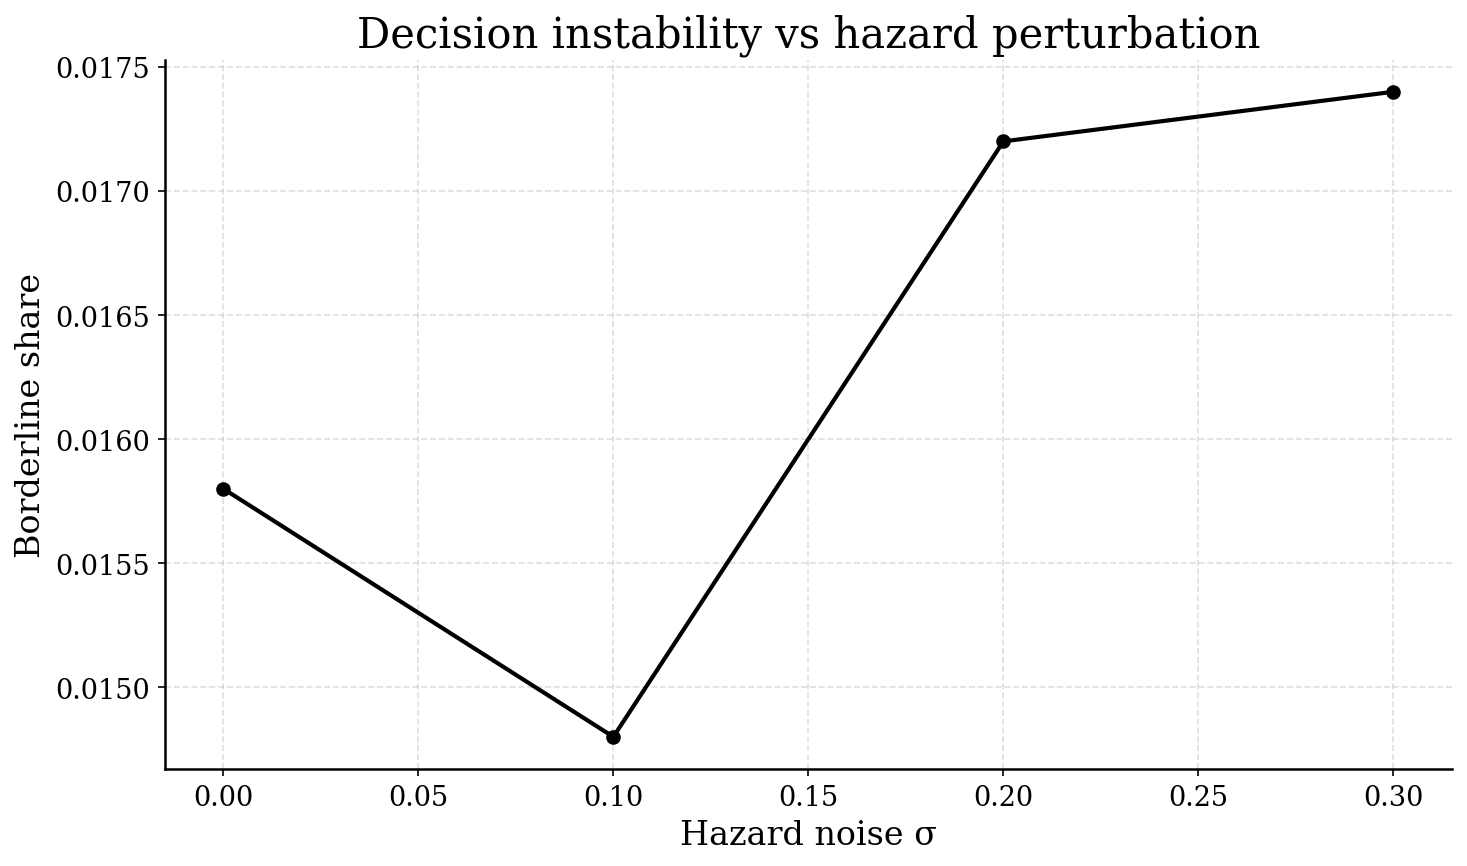

In [33]:
import matplotlib.pyplot as plt

sigmas = [0.00, 0.10, 0.20, 0.30]
borderline = [0.0158, 0.0148, 0.0172, 0.0174]

fig_line, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    sigmas,
    borderline,
    color="black",
    marker="o",
    markerfacecolor="black",
    markeredgecolor="black"
)

ax.set_xlabel("Hazard noise σ")
ax.set_ylabel("Borderline share")
ax.set_title("Decision instability vs hazard perturbation")

ax.grid(True, linestyle="--", alpha=0.4)

fig_line.tight_layout()
plt.show()

In [34]:
fig_line.savefig(OUTPUT_DIR / "borderline_vs_sigma.png", bbox_inches="tight")
fig_line.savefig(OUTPUT_DIR / "borderline_vs_sigma.svg", bbox_inches="tight")

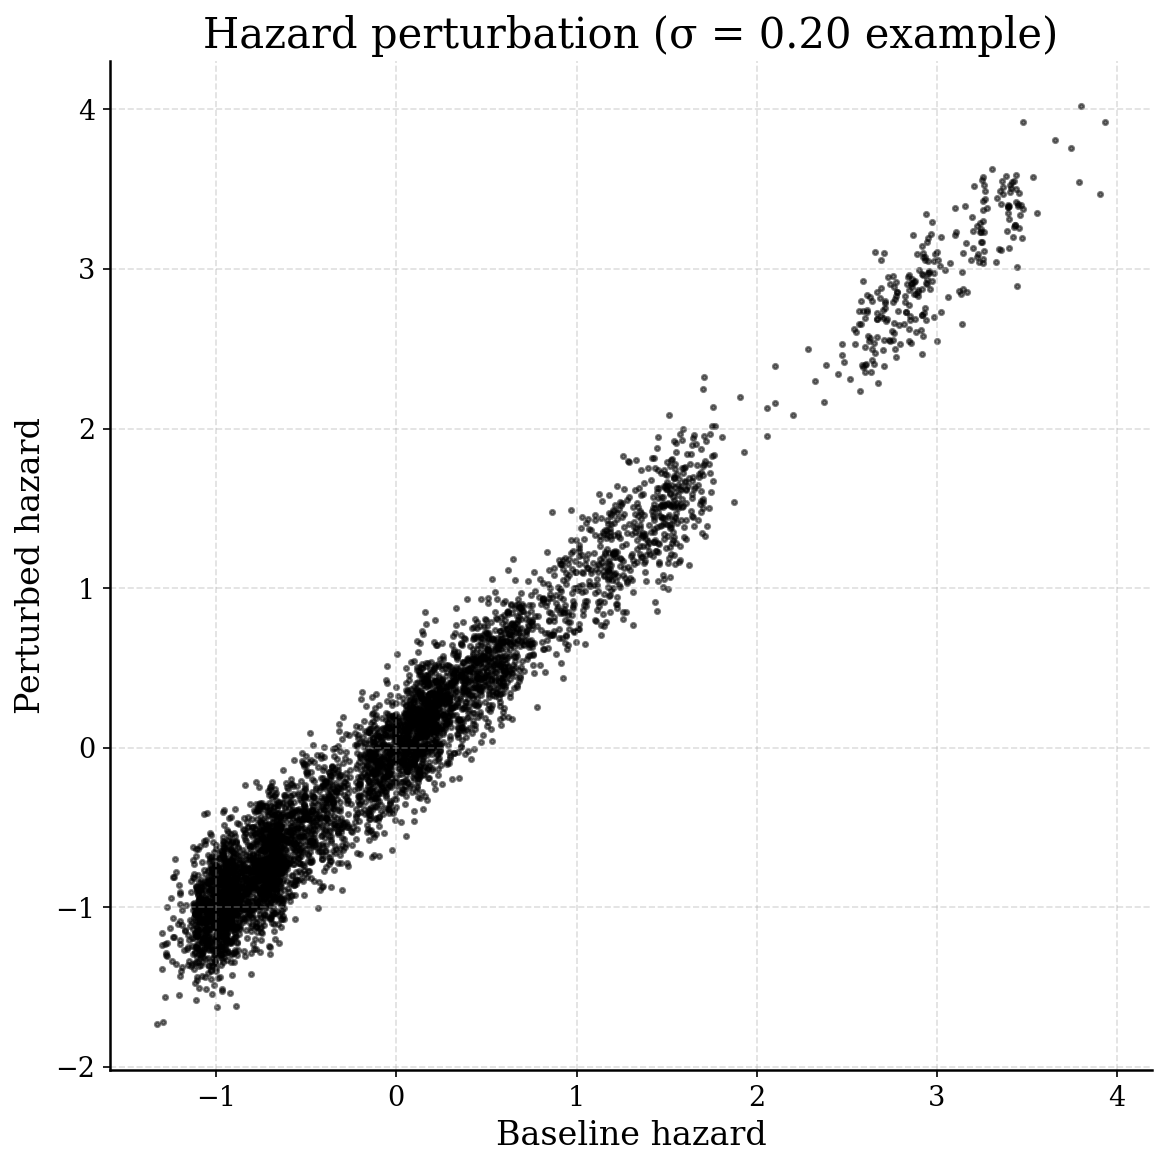

In [35]:
fig_scatter, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    df["H_std_base"],
    df["H_std"],
    s=5,
    color="black",
    alpha=0.5
)

ax.set_xlabel("Baseline hazard")
ax.set_ylabel("Perturbed hazard")
ax.set_title(f"Hazard perturbation (σ = {SIGMA:.2f} example)")

ax.grid(True, linestyle="--", alpha=0.4)

fig_scatter.tight_layout()
plt.show()

In [36]:
fig_scatter.savefig(OUTPUT_DIR / f"hazard_scatter_sigma_{int(SIGMA*100):03d}.png", bbox_inches="tight")
fig_scatter.savefig(OUTPUT_DIR / f"hazard_scatter_sigma_{int(SIGMA*100):03d}.svg", bbox_inches="tight")

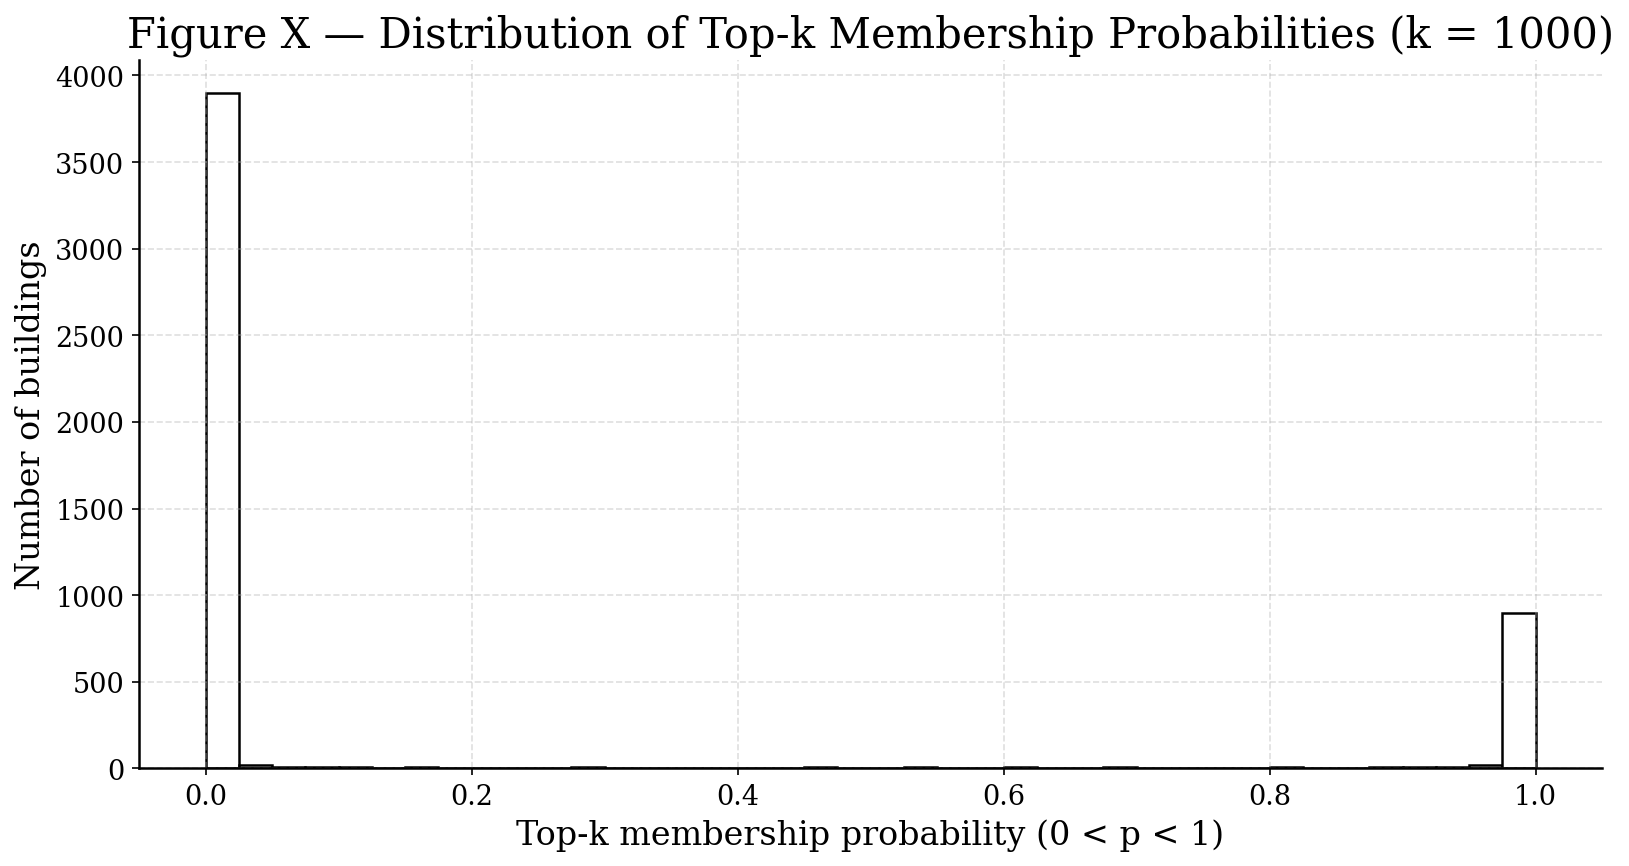

In [37]:
fig_hist, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    df["topk_prob"],
    bins=40,
    color="white",          # fill
    edgecolor="black",      # outline
    linewidth=1.2
)

ax.set_title("Figure X — Distribution of Top-k Membership Probabilities (k = 1000)")
ax.set_xlabel("Top-k membership probability (0 < p < 1)")
ax.set_ylabel("Number of buildings")

fig_hist.tight_layout()
plt.show()

In [38]:
fig_hist.savefig(OUTPUT_DIR / "distribution_top-k_membership_probabilities.png", bbox_inches="tight")
fig_hist.savefig(OUTPUT_DIR / "distribution_top-k_membership_probabilities.svg", bbox_inches="tight")

In [39]:
summary = {
    "sigma": SIGMA,
    "borderline_share": float(borderline_share),
    "n_assets": len(df),
    "seed": SEED,
}

save_json(summary, OUTPUT_DIR / "summary.json")

# =========================================
# Phase 2 — Closure (σ = 0.05 + summary)
# =========================================

In [51]:
# --- Closure run: sigma = 0.05 from clean baseline ---

SIGMA_CLOSURE = 0.05
EXPERIMENT_CLOSURE = "hazard_noise_sigma_005"
OUTPUT_DIR_CLOSURE = REPO_ROOT / "outputs" / "phase2" / EXPERIMENT_CLOSURE
OUTPUT_DIR_CLOSURE.mkdir(parents=True, exist_ok=True)

# Start from clean standardized hazard, not the currently perturbed one
df_closure = df.copy()
df_closure["H_std"] = df_closure["H_std_base"].copy()
df_closure["H_std"] = perturb_hazard(
    df_closure["H_std"].values,
    sigma=SIGMA_CLOSURE,
    seed=SEED,
)

print("Closure run:")
print("Experiment:", EXPERIMENT_CLOSURE)
print("H_std mean/std:", df_closure["H_std"].mean(), df_closure["H_std"].std(ddof=1))
print("Correlation H_std_base vs H_std:", np.corrcoef(df_closure["H_std_base"], df_closure["H_std"])[0, 1])

Closure run:
Experiment: hazard_noise_sigma_005
H_std mean/std: -0.0009994159949061213 1.000777869530452
Correlation H_std_base vs H_std: 0.9987526362512718


In [52]:
coords_closure = {"obs_id": np.arange(len(df_closure))}

with pm.Model(coords=coords_closure) as model_closure:

    E_data = pm.Data("E_std", df_closure["E_std"].values, dims="obs_id")
    H_data = pm.Data("H_std", df_closure["H_std"].values, dims="obs_id")

    alpha = pm.Normal("alpha", mu=0, sigma=2.5)
    beta_E = pm.Normal("beta_E", mu=0, sigma=2.5)
    beta_H = pm.Normal("beta_H", mu=0, sigma=2.5)

    logit_p = alpha + beta_E * E_data + beta_H * H_data
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")

    Y_obs = pm.Bernoulli(
        "Y_obs",
        p=p,
        observed=df_closure["Y_damage_v1b"].values,
        dims="obs_id",
    )

    idata_closure = pm.sample(
        draws=500,
        tune=500,
        chains=2,
        cores=2,
        target_accept=0.9,
        random_seed=SEED,
        return_inferencedata=True,
    )

/Users/habnetic/habnetic/projects/resilient-housing-bayes/.venv/lib/python3.11/site-packages/pymc/data.py:433: UserWarning: The `mutable` kwarg was not specified. Before v4.1.0 it defaulted to `pm.Data(mutable=True)`, which is equivalent to using `pm.MutableData()`. In v4.1.0 the default changed to `pm.Data(mutable=False)`, equivalent to `pm.ConstantData`. Use `pm.ConstantData`/`pm.MutableData` or pass `pm.Data(..., mutable=False/True)` to avoid this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, beta_E, beta_H]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 25 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [53]:
# Posterior mean probability per building
p_post_closure = idata_closure.posterior["p"].mean(dim=("chain", "draw")).values
df_closure["p_post_mean"] = p_post_closure

# Rank by posterior mean
df_closure["rank_post_mean"] = df_closure["p_post_mean"].rank(ascending=False)

# Top-k membership probability
p_samples_closure = idata_closure.posterior["p"].stack(sample=("chain", "draw")).values

topk_counts_closure = np.zeros(len(df_closure))

for s in range(p_samples_closure.shape[1]):
    idx = np.argsort(-p_samples_closure[:, s])[:TOP_K]
    topk_counts_closure[idx] += 1

topk_prob_closure = topk_counts_closure / p_samples_closure.shape[1]
df_closure["topk_prob"] = topk_prob_closure

borderline_005 = ((df_closure["topk_prob"] > 0.2) & (df_closure["topk_prob"] < 0.8)).mean()

print("Top-k probability summary (σ = 0.05):")
print(df_closure["topk_prob"].describe())
print("Borderline share (σ = 0.05):", borderline_005)

Top-k probability summary (σ = 0.05):
count    5000.000000
mean        0.200000
std         0.393902
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: topk_prob, dtype: float64
Borderline share (σ = 0.05): 0.013


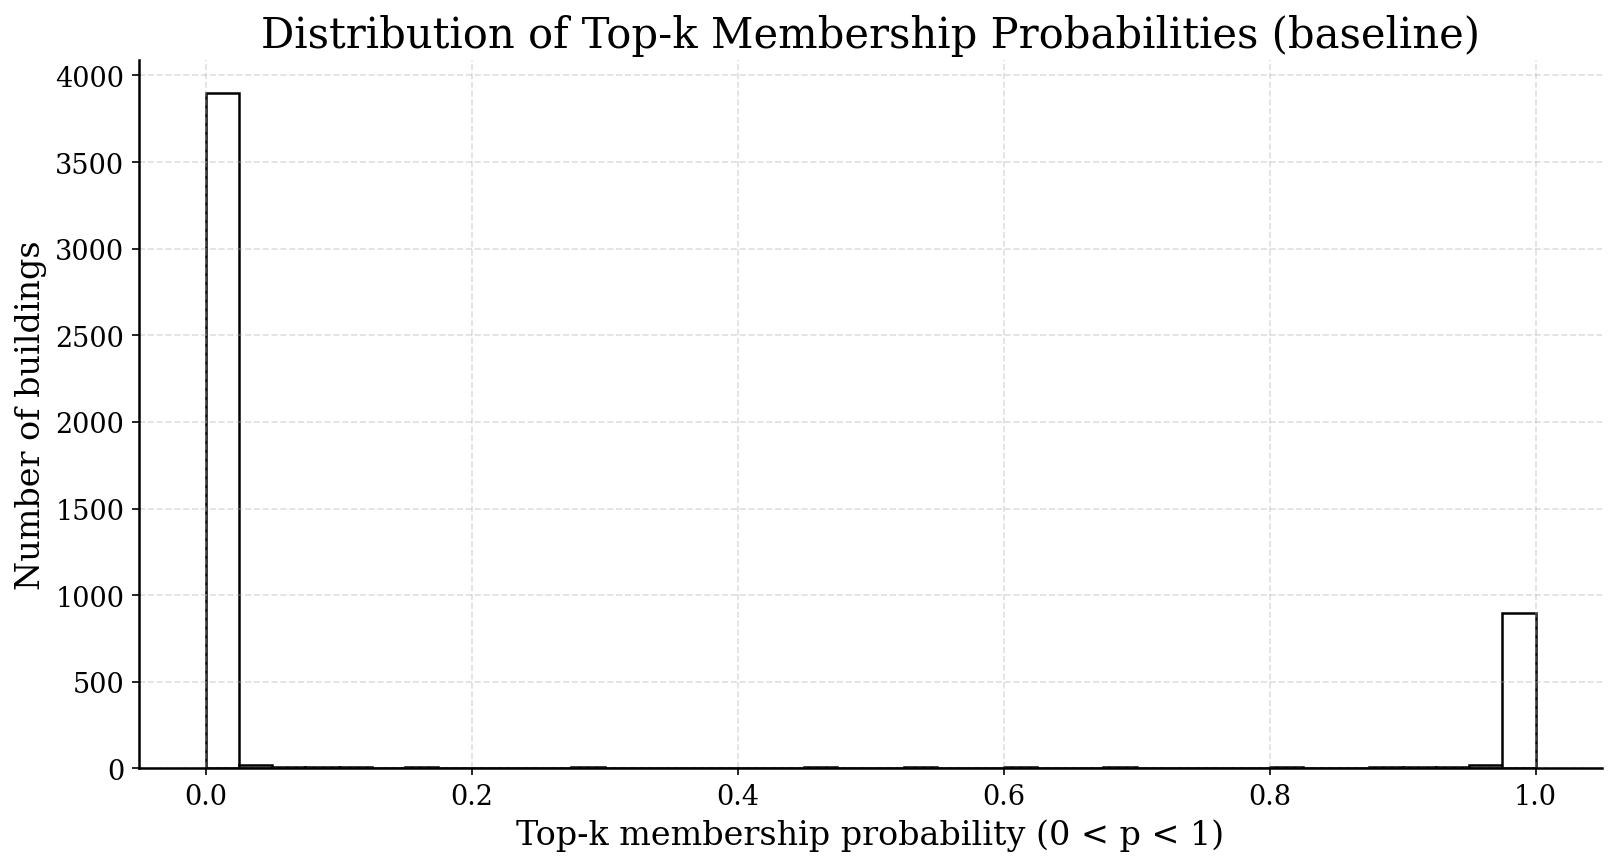

In [54]:
fig_hist, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    df["topk_prob"],
    bins=40,
    color="white",
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Distribution of Top-k Membership Probabilities (baseline)")
ax.set_xlabel("Top-k membership probability (0 < p < 1)")
ax.set_ylabel("Number of buildings")

fig_hist.tight_layout()

fig_hist.savefig(REPO_ROOT / "outputs" / "phase2" / "reference_baseline" / "distribution_top-k_membership_probabilities.png", bbox_inches="tight")
fig_hist.savefig(REPO_ROOT / "outputs" / "phase2" / "reference_baseline" / "distribution_top-k_membership_probabilities.svg", bbox_inches="tight")

plt.show()

In [55]:
fig_hist.savefig(REPO_ROOT / "outputs" / "phase2" / "hazard_noise_sigma_005" / "distribution_top-k_membership_probabilities.png", bbox_inches="tight")
fig_hist.savefig(REPO_ROOT / "outputs" / "phase2" / "hazard_noise_sigma_005" / "distribution_top-k_membership_probabilities.svg", bbox_inches="tight")

In [50]:
summary_005 = {
    "experiment": EXPERIMENT_CLOSURE,
    "sigma": SIGMA_CLOSURE,
    "seed": SEED,
    "top_k": TOP_K,
    "n_assets": int(len(df_closure)),
    "borderline_share": float(borderline_005),
    "hazard_correlation": float(np.corrcoef(df_closure["H_std_base"], df_closure["H_std"])[0, 1]),
}

save_json(summary_005, OUTPUT_DIR_CLOSURE / "summary.json")

df_closure[[
    "bldg_id",
    "E_std",
    "H_std_base",
    "H_std",
    "p_post_mean",
    "rank_post_mean",
    "topk_prob",
]].to_parquet(OUTPUT_DIR_CLOSURE / "asset_metrics.parquet", index=False)

az.to_netcdf(idata_closure, OUTPUT_DIR_CLOSURE / "idata.nc")

print("Saved closure outputs to:", OUTPUT_DIR_CLOSURE)

Saved closure outputs to: /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/hazard_noise_sigma_005


In [44]:
results = pd.DataFrame({
    "sigma": [0.00, 0.05, 0.10, 0.20, 0.30],
    "borderline_share": [0.0158, borderline_005, 0.0148, 0.0172, 0.0174],
})

results["approx_borderline_buildings"] = (results["borderline_share"] * N).round().astype(int)

results

,sigma,borderline_share,approx_borderline_buildings
0,0.00,0.0158,79
1,0.05,0.0130,65
2,0.10,0.0148,74
3,0.20,0.0172,86
4,0.30,0.0174,87


In [45]:
OUTPUT_DIR_SUMMARY = REPO_ROOT / "outputs" / "phase2"
OUTPUT_DIR_SUMMARY.mkdir(parents=True, exist_ok=True)

results.to_csv(OUTPUT_DIR_SUMMARY / "phase2_summary.csv", index=False)
results.to_parquet(OUTPUT_DIR_SUMMARY / "phase2_summary.parquet", index=False)

print("Saved:")
print("-", OUTPUT_DIR_SUMMARY / "phase2_summary.csv")
print("-", OUTPUT_DIR_SUMMARY / "phase2_summary.parquet")

Saved:
- /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/phase2_summary.csv
- /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/phase2_summary.parquet


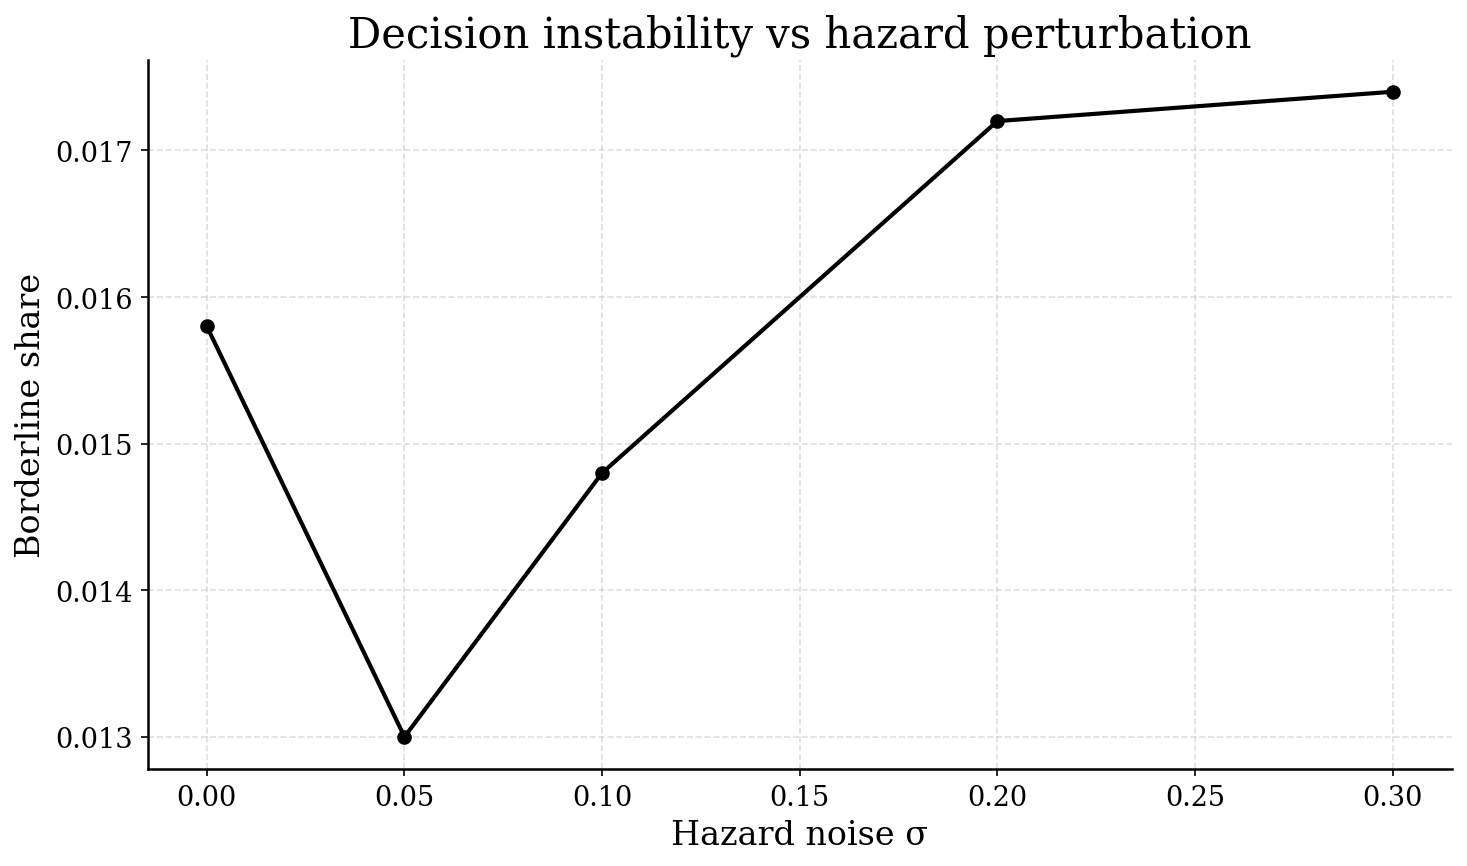

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    results["sigma"],
    results["borderline_share"],
    color="black",
    marker="o",
    markerfacecolor="black",
    markeredgecolor="black"
)

ax.set_xlabel("Hazard noise σ")
ax.set_ylabel("Borderline share")
ax.set_title("Decision instability vs hazard perturbation")
ax.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()

In [47]:
fig.savefig(OUTPUT_DIR_SUMMARY / "borderline_vs_sigma_full.png", bbox_inches="tight")
fig.savefig(OUTPUT_DIR_SUMMARY / "borderline_vs_sigma_full.svg", bbox_inches="tight")

print("Saved:")
print("-", OUTPUT_DIR_SUMMARY / "borderline_vs_sigma_full.png")
print("-", OUTPUT_DIR_SUMMARY / "borderline_vs_sigma_full.svg")

Saved:
- /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/borderline_vs_sigma_full.png
- /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/borderline_vs_sigma_full.svg


In [48]:
REFERENCE_DIR = REPO_ROOT / "outputs" / "phase2" / "reference_baseline"
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

baseline_summary = {
    "experiment": "baseline_sigma_000",
    "sigma": 0.00,
    "seed": SEED,
    "top_k": TOP_K,
    "n_assets": int(N),
    "borderline_share": 0.0158,
    "notes": "Baseline reference from notebook 15; no hazard perturbation applied."
}

save_json(baseline_summary, REFERENCE_DIR / "baseline_summary.json")

print("Saved baseline reference summary to:", REFERENCE_DIR)

Saved baseline reference summary to: /Users/habnetic/habnetic/projects/resilient-housing-bayes/outputs/phase2/reference_baseline


In [49]:
summary = pd.DataFrame({
    "sigma": [0.00, 0.05, 0.10, 0.20, 0.30],
    "borderline_share": [0.0158, 0.0130, 0.0148, 0.0172, 0.0174],
})

summary.to_csv(OUTPUT_DIR / "phase2_summary.csv", index=False)